# Introduction

Dans un contexte marqué par les enjeux croissants de transition écologique, la transparence environnementale des entreprises occupe une place de plus en plus centrale. Les investisseurs, les régulateurs et plus largement les parties prenantes attendent aujourd’hui des entreprises qu’elles communiquent de manière claire sur leurs performances environnementales. Dans ce cadre, le CDP Survey, mis en place par l’organisation CDP, s’impose comme un outil de référence permettant d’évaluer et de comparer l’engagement environnemental des entreprises à l’échelle internationale.

Cependant, la participation à ce questionnaire repose sur le volontariat, et toutes les entreprises ne choisissent pas d’y répondre. Ce constat soulève une question essentielle : pourquoi certaines entreprises participent-elles au CDP Survey tandis que d’autres s’en abstiennent ? Autrement dit, quels sont les facteurs qui influencent la décision de transparence environnementale des entreprises ?

L’objectif de ce travail est donc d’identifier et d’analyser les déterminants de la participation au CDP, à partir d’un échantillon d’entreprises de l’indice EURO STOXX 600. Il s’agit en particulier d’évaluer le rôle de la performance environnementale, de la gouvernance et des caractéristiques économiques dans cette décision, à l’aide d’un modèle économétrique adapté à une variable binaire.

L’intérêt économique de cette étude est double. D’une part, elle permet de mieux comprendre les mécanismes qui poussent les entreprises à adopter des pratiques de transparence environnementale. D’autre part, elle apporte des éléments utiles pour les investisseurs et les décideurs publics dans un contexte de transition vers une économie plus durable.

Le travail est structuré comme suit. Dans une première partie, nous présentons les données et les variables utilisées. La deuxième partie est consacrée aux statistiques descriptives et à l’analyse exploratoire. La troisième partie introduit la méthodologie économétrique retenue. La quatrième partie présente les résultats d’estimation et leur évaluation. Enfin, la dernière partie propose une interprétation économique des résultats ainsi qu’un choix du modèle le plus pertinent.

# Partie 2 — Répond ou ne répond pas au CDP Survey

L’objectif de cette étude est d’identifier les facteurs qui expliquent la décision d’une entreprise de répondre ou non au questionnaire CDP.

La variable dépendante est `Res`, une variable binaire :

- `Res = 1` : l’entreprise répond au CDP Survey
- `Res = 0` : l’entreprise ne répond pas

Compte tenu de la nature binaire de cette variable, l’analyse économétrique reposera principalement sur un modèle logit ou probit.

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc

# Chargement de la base

In [8]:
df = pd.read_excel("../data/stoxx_600_donnees_270426_projetBIDABI.xlsx")

In [9]:
df.head()

,Unnamed: 0,Identifier (RIC),Market Cap,ISIN Code,EMPLOYEES,PROFIT,Environment Pillar Score,CSR Sustainability Committee,RETURN ON INVESTED CAPITAL,Value - Board Structure/Independent Board Members,Res.=
0,582,DBKGn.DE,1.925878e+10,DE0005140008,87597,3.41,95.85,Y,-1.06,47.83,1
1,324,BMWG.DE,5.072027e+10,DE0005190003,133778,6.90,90.57,Y,3.05,100.00,1
2,556,BEIG.DE,2.393679e+10,DE0005200000,20654,12.92,73.82,Y,11.81,23.53,1
3,189,AFXG.DE,1.040119e+10,DE0005313704,3232,18.14,67.45,Y,11.29,28.57,1
4,301,CONG.DE,1.327240e+10,DE0005439004,241458,2.50,78.53,Y,-4.62,25.00,1


# Nettoyage

In [10]:
df = df.rename(columns={
    "Market Cap": "Market_Cap",
    "Environment Pillar Score": "EPS",
    "CSR Sustainability Committee": "CSR",
    "RETURN ON INVESTED CAPITAL": "ROIC",
    "Value - Board Structure/Independent Board Members": "Board",
    "Res.=": "Res"
})

df["CSR"] = df["CSR"].astype(str).str.strip()
df["CSR"] = df["CSR"].map({"Y": 1, "N": 0})

df = df.drop(columns=[
    "Unnamed: 0",
    "Identifier (RIC)",
    "ISIN Code"
], errors="ignore")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 552 entries, 0 to 551
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Market_Cap  552 non-null    float64
 1   EMPLOYEES   552 non-null    int64  
 2   PROFIT      552 non-null    float64
 3   EPS         552 non-null    float64
 4   CSR         552 non-null    int64  
 5   ROIC        552 non-null    float64
 6   Board       552 non-null    float64
 7   Res         552 non-null    int64  
dtypes: float64(5), int64(3)
memory usage: 34.6 KB


In [11]:
df["Res"].value_counts()

Res
1    313
0    239
Name: count, dtype: int64

# 1. PRESENTATION DES DONNEES

## 1.1 Description de la base

L’analyse repose sur un échantillon de 552 entreprises européennes issues de l’indice EURO STOXX.

L’objectif de cette étude est d’identifier les déterminants de la participation des entreprises au CDP Survey (Carbon Disclosure Project), une enquête internationale portant sur la transparence environnementale des entreprises.

Chaque observation correspond à une entreprise caractérisée par des variables financières, organisationnelles et environnementales. Les données utilisées sont issues de la base REFINITIV.

---

## 1.2 Présentation des variables

### Variable expliquée

La variable dépendante est la variable **Res**, définie comme suit :

- Res = 1 : l’entreprise répond au CDP Survey  
- Res = 0 : l’entreprise ne répond pas  

Il s’agit d’une variable binaire, ce qui justifie l’utilisation d’un modèle économétrique de type logit ou probit.

---

### Variables explicatives

Les variables explicatives retenues sont les suivantes :

- **Market_Cap** : capitalisation boursière de l’entreprise (taille financière)  
- **EMPLOYEES** : nombre d’employés (taille organisationnelle)  
- **PROFIT** : profit de l’entreprise  
- **EPS** : score de performance environnementale  
- **CSR** : présence d’un comité de responsabilité sociale (1 = oui, 0 = non)  
- **ROIC** : rendement du capital investi  
- **Board** : pourcentage de membres indépendants dans le conseil d’administration  

Ces variables permettent de capter différentes dimensions influençant la décision de participation : gouvernance, performance environnementale et caractéristiques économiques.

---

### Typologie des variables

On distingue :

- Variables quantitatives : Market_Cap, EMPLOYEES, PROFIT, EPS, ROIC, Board  
- Variables qualitatives binaires : CSR (explicative) et Res (variable dépendante)

# 2. STATISTIQUES DESCRIPTIVES 
## 2.1 Variables quantitatives

L’analyse des variables quantitatives permet de décrire les principales caractéristiques des entreprises de l’échantillon.

Le tableau ci-dessous présente les statistiques descriptives usuelles : moyenne, écart-type, valeurs extrêmes et quartiles.


In [13]:
df.describe()

,Market_Cap,EMPLOYEES,PROFIT,EPS,CSR,ROIC,Board,Res
count,5.520000e+02,552.000000,552.000000,552.000000,552.000000,552.000000,552.000000,552.000000
mean,4.135149e+10,41671.070652,20.694946,64.093659,0.807971,11.019583,64.064529,0.567029
std,9.461945e+10,73429.256312,54.351355,23.355232,0.394253,20.907714,22.803908,0.495936
min,1.480459e+09,0.000000,-275.780000,0.000000,0.000000,-38.140000,0.000000,0.000000
25%,5.548407e+09,4288.750000,7.470000,49.395000,1.000000,4.610000,50.000000,0.000000
50%,1.347467e+10,14713.500000,12.930000,69.040000,1.000000,8.230000,64.855000,1.000000
75%,3.672482e+10,45985.000000,23.052500,83.000000,1.000000,13.772500,80.000000,1.000000
max,1.322439e+12,671205.000000,731.440000,98.160000,1.000000,437.740000,100.000000,1.000000


### Interprétation

L’analyse des statistiques descriptives met en évidence plusieurs caractéristiques importantes de l’échantillon.

Tout d’abord, les variables de taille, telles que la capitalisation boursière (Market_Cap) et le nombre d’employés (EMPLOYEES), présentent une forte dispersion. En effet, l’écart-type est très élevé par rapport à la moyenne, et les valeurs maximales sont largement supérieures aux valeurs médianes. Cela traduit une forte hétérogénéité des entreprises, avec la présence de très grandes entreprises aux côtés d’entreprises de taille plus modeste.

Ensuite, la variable de profit (PROFIT) présente une moyenne positive, mais avec des valeurs minimales négatives importantes. Cela indique que certaines entreprises de l’échantillon sont déficitaires, ce qui reflète une diversité de situations économiques.

Le score environnemental (EPS) est en moyenne relativement élevé (64,09), avec une médiane encore plus élevée (69,04), ce qui suggère que la majorité des entreprises ont une performance environnementale satisfaisante. Cependant, la présence de valeurs faibles montre que certaines entreprises restent peu performantes sur ce plan.

Le rendement du capital investi (ROIC) présente une très forte variabilité, avec des valeurs extrêmes importantes. Cela traduit des différences significatives de performance financière entre les entreprises.

Concernant la gouvernance, le pourcentage d’administrateurs indépendants (Board) est élevé en moyenne (64,06 %), ce qui indique que les entreprises disposent généralement d’une structure de gouvernance relativement indépendante.

Enfin, les variables binaires montrent que :
- une grande majorité des entreprises disposent d’un comité de responsabilité sociale (CSR = 1 dans plus de 80 % des cas),
- environ 56,7 % des entreprises répondent au CDP Survey, ce qui indique une participation relativement élevée.

Dans l’ensemble, ces résultats mettent en évidence une forte hétérogénéité des entreprises, ainsi qu’un niveau globalement élevé de performance environnementale et de gouvernance, ce qui pourrait influencer la décision de participation au CDP Survey.

# Visualisations graphiques
# Market Cap

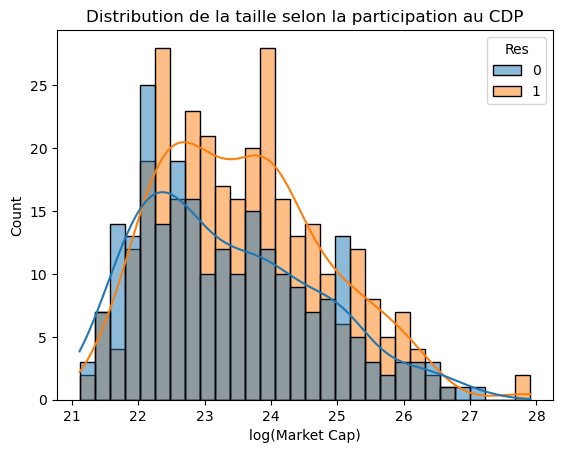

In [17]:
import seaborn as sns

sns.histplot(data=df, x=np.log(df["Market_Cap"]), hue="Res", bins=30, kde=True)
plt.title("Distribution de la taille selon la participation au CDP")
plt.xlabel("log(Market Cap)")
plt.show()

La distribution de la capitalisation boursière (en logarithme) selon la participation au CDP met en évidence des différences intéressantes entre les entreprises répondantes et non répondantes.

On observe que les entreprises répondant au CDP (Res = 1) sont globalement plus concentrées sur des niveaux de capitalisation plus élevés. À l’inverse, les entreprises ne répondant pas (Res = 0) sont davantage représentées parmi les entreprises de plus petite taille.

Cette différence suggère que la taille de l’entreprise joue un rôle important dans la décision de participation. Les grandes entreprises disposent généralement de plus de ressources financières et organisationnelles, ce qui peut faciliter la mise en place de stratégies de transparence environnementale et la réponse à des enquêtes telles que le CDP.

Ainsi, cette première analyse graphique indique une relation positive potentielle entre la taille de l’entreprise et la probabilité de participation au CDP, ce qui constitue une hypothèse qui sera testée dans la suite de l’analyse économétrique.

# EPS

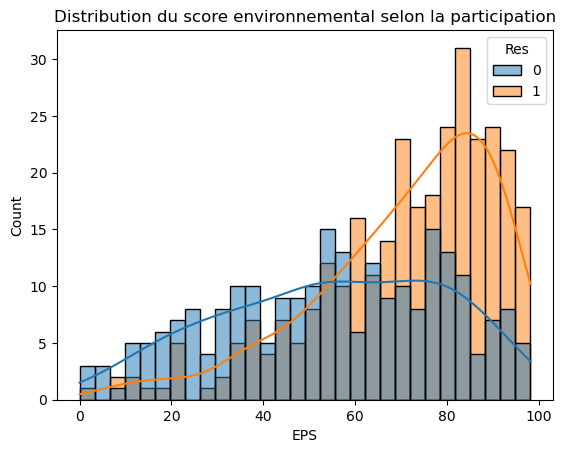

In [18]:
sns.histplot(data=df, x="EPS", hue="Res", bins=30, kde=True)
plt.title("Distribution du score environnemental selon la participation")
plt.show()

La distribution du score environnemental (EPS) selon la participation au CDP met en évidence une différence marquée entre les entreprises répondantes et non répondantes.

Les entreprises répondant au CDP (Res = 1) présentent des scores environnementaux significativement plus élevés, avec une concentration importante autour des valeurs comprises entre 70 et 90. À l’inverse, les entreprises ne répondant pas sont davantage représentées parmi les niveaux de performance environnementale plus faibles.

Cette observation suggère que les entreprises les plus engagées sur le plan environnemental sont également celles qui adoptent des pratiques de transparence, notamment en participant au CDP.

Ainsi, la performance environnementale apparaît comme un déterminant clé de la participation au CDP, ce qui est cohérent avec l’objectif même de cette enquête.

Cette relation sera testée formellement dans l’analyse économétrique.

# ROIC

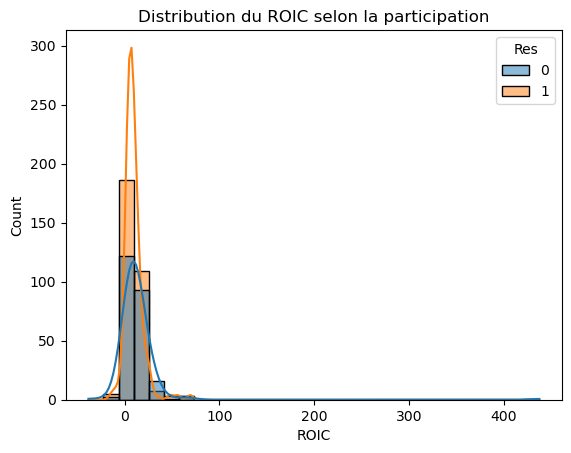

In [19]:
sns.histplot(data=df, x="ROIC", hue="Res", bins=30, kde=True)
plt.title("Distribution du ROIC selon la participation")
plt.show()

La distribution du rendement du capital investi (ROIC) selon la participation au CDP présente une forte concentration autour de valeurs faibles, avec la présence de valeurs extrêmes.

On observe que la majorité des entreprises, qu’elles répondent ou non au CDP, ont des niveaux de ROIC relativement proches de zéro. La distribution est fortement asymétrique, avec quelques valeurs très élevées qui traduisent des situations exceptionnelles.

Contrairement aux variables précédentes, la différence entre les entreprises répondantes et non répondantes apparaît moins marquée. Les deux distributions se recouvrent largement, ce qui suggère que la performance financière mesurée par le ROIC n’est pas un facteur déterminant évident de la participation au CDP.

Ces résultats indiquent que, bien que la performance financière puisse jouer un rôle, son impact est probablement moins direct que celui de la taille ou de la performance environnementale.

## 2.2 Variables qualitatives

Cette section présente les variables qualitatives de la base de données.  
L’objectif est d’analyser leur répartition dans l’échantillon à partir des fréquences et des pourcentages.

Deux variables binaires sont étudiées :

- **CSR** : présence ou non d’un comité de responsabilité sociale ;
- **Res** : participation ou non de l’entreprise au CDP Survey.

Cette analyse permet d’obtenir une première lecture de la structure de l’échantillon avant l’analyse économétrique.

# Fréquences et pourcentages 

In [20]:
# Fréquences et pourcentages pour les variables qualitatives

qualitatives = ["CSR", "Res"]

for var in qualitatives:
    freq = df[var].value_counts().sort_index()
    pct = df[var].value_counts(normalize=True).sort_index() * 100
    
    tableau = pd.DataFrame({
        "Fréquence": freq,
        "Pourcentage (%)": pct.round(2)
    })
    
    print(f"\nVariable : {var}")
    display(tableau)


Variable : CSR


,Fréquence,Pourcentage (%)
CSR,,
0,106,19.2
1,446,80.8



Variable : Res


,Fréquence,Pourcentage (%)
Res,,
0,239,43.3
1,313,56.7



La variable CSR montre que 80,8 % des entreprises disposent d’un comité de responsabilité sociale, ce qui indique une forte diffusion des pratiques de gouvernance responsables au sein de l’échantillon.

La variable Res indique que 56,7 % des entreprises participent au CDP Survey, ce qui reflète un niveau relativement élevé d’engagement en matière de transparence environnementale.

Cependant, une proportion non négligeable d’entreprises (43,3 %) ne participe pas, ce qui justifie l’analyse des facteurs expliquant cette décision dans la suite de l’étude.

# Visualisation

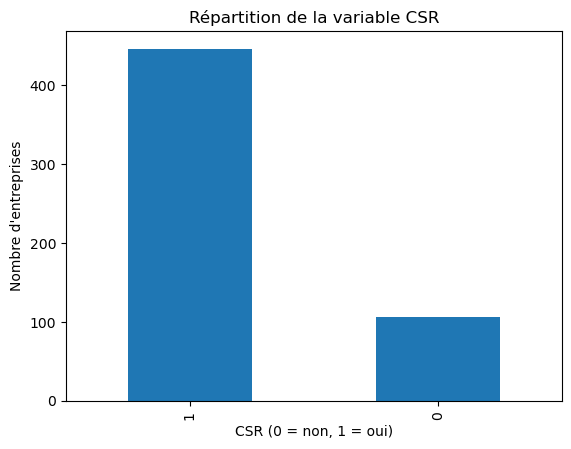

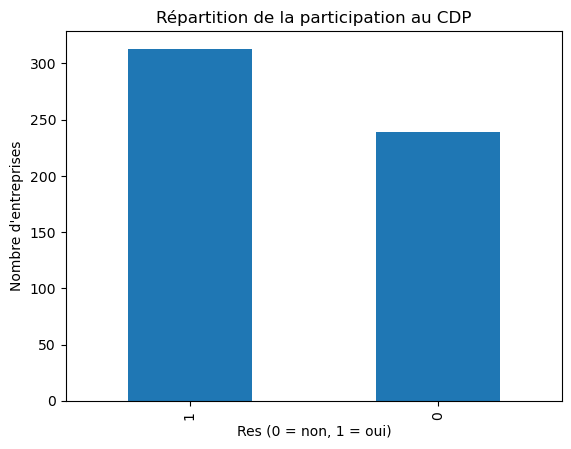

In [21]:
# CSR
df["CSR"].value_counts().plot(kind="bar")
plt.title("Répartition de la variable CSR")
plt.xlabel("CSR (0 = non, 1 = oui)")
plt.ylabel("Nombre d'entreprises")
plt.show()

# Res
df["Res"].value_counts().plot(kind="bar")
plt.title("Répartition de la participation au CDP")
plt.xlabel("Res (0 = non, 1 = oui)")
plt.ylabel("Nombre d'entreprises")
plt.show()

### Interprétation des graphiques

Les graphiques confirment les résultats obtenus à partir des tableaux de fréquences.

Concernant la variable CSR, on observe une très forte majorité d’entreprises disposant d’un comité de responsabilité sociale. Cela traduit une adoption généralisée des pratiques de gouvernance responsables au sein des entreprises de l’échantillon.

S’agissant de la variable Res, la répartition est plus équilibrée. Bien qu’une majorité d’entreprises participent au CDP, une proportion importante ne le fait pas, ce qui met en évidence l’existence d’un comportement hétérogène en matière de transparence environnementale.

Ces résultats justifient l’analyse des facteurs susceptibles d’expliquer cette participation dans la suite de l’étude.

## 2.3 Analyse bivariée

L’analyse bivariée permet d’étudier les relations entre la variable dépendante (Res) et les différentes variables explicatives.

L’objectif est d’identifier les facteurs susceptibles d’influencer la participation au CDP Survey, avant l’estimation du modèle économétrique.

Cette analyse repose sur :
- l’étude des corrélations,
- des tableaux croisés,
- des tests statistiques,
- ainsi que des premières interprétations économiques.

# Corrélations

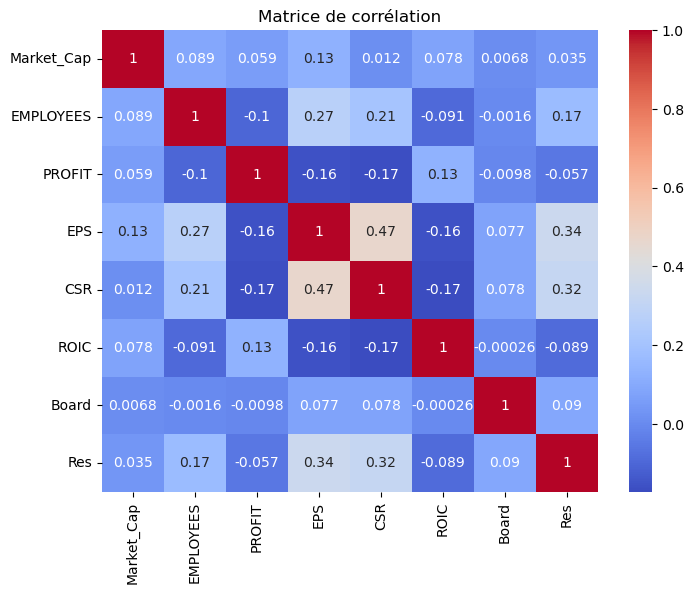

In [22]:
corr = df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.show()


La matrice de corrélation permet d’identifier les relations linéaires entre les variables explicatives et la participation au CDP.

Concernant la variable dépendante (Res), on observe que :

- le score environnemental (EPS) présente une corrélation positive relativement élevée (0,34), ce qui suggère que les entreprises ayant de meilleures performances environnementales sont plus susceptibles de participer au CDP ;
- la variable CSR est également positivement corrélée avec la participation (0,32), indiquant que les entreprises disposant d’un comité de responsabilité sociale sont davantage engagées dans des démarches de transparence ;
- le nombre d’employés (EMPLOYEES) présente une corrélation positive plus faible (0,17), ce qui suggère un effet de la taille organisationnelle ;
- la capitalisation boursière (Market_Cap) est faiblement corrélée avec la participation (0,035), ce qui indique que la taille financière joue un rôle limité en première analyse ;
- le ROIC est légèrement négativement corrélé (-0,089), ce qui suggère un effet ambigu de la performance financière ;
- la variable Board présente une corrélation faible (0,09), traduisant un effet limité de la gouvernance dans cette dimension.

Par ailleurs, certaines corrélations entre variables explicatives sont notables, notamment entre EPS et CSR (0,47), ce qui suggère que les entreprises les plus engagées sur le plan environnemental sont également celles qui mettent en place des structures de gouvernance responsables.

Dans l’ensemble, ces résultats indiquent que la performance environnementale et les pratiques de responsabilité sociale sont les principaux facteurs associés à la participation au CDP.

# Tableaux croisés

In [23]:
pd.crosstab(df["CSR"], df["Res"], normalize="index") * 100

Res,0,1
CSR,,
0,75.471698,24.528302
1,35.650224,64.349776


### Tableaux croisés

Le tableau croisé entre la variable CSR et la participation au CDP met en évidence une relation très marquée.

Parmi les entreprises ne disposant pas d’un comité de responsabilité sociale (CSR = 0), seulement 24,5 % participent au CDP, tandis que 75,5 % n’y participent pas.

À l’inverse, parmi les entreprises disposant d’un comité CSR (CSR = 1), près de 64,3 % participent au CDP.

Cette différence importante suggère que la présence d’un comité de responsabilité sociale joue un rôle déterminant dans la décision de participation au CDP.

Ces résultats confirment que les entreprises engagées dans des pratiques de gouvernance responsables sont plus enclines à adopter des comportements de transparence environnementale.

# T-Test

#  Test de comparaison de moyennes (EPS)

In [26]:
from scipy.stats import ttest_ind

res0 = df[df["Res"]==0]["EPS"]
res1 = df[df["Res"]==1]["EPS"]

ttest_ind(res0, res1)

TtestResult(statistic=np.float64(-8.464831164464652), pvalue=np.float64(2.337943375219486e-16), df=np.float64(550.0))

In [27]:
res0.mean(), res1.mean()

(np.float64(55.027824267782435), np.float64(71.01613418530351))


Un test de Student a été réalisé afin de comparer le score environnemental (EPS) entre les entreprises participant au CDP (Res = 1) et celles n’y participant pas (Res = 0).

Les résultats montrent que les entreprises non répondantes présentent un score environnemental moyen de 55,03, contre 71,02 pour les entreprises répondantes.

Le test donne une statistique t de -8,46 et une p-value très faible (p < 0,01), ce qui permet de rejeter l’hypothèse d’égalité des moyennes.

Ainsi, les entreprises répondantes présentent en moyenne un score environnemental significativement plus élevé que les entreprises non répondantes.

Ce résultat met en évidence une différence importante de performance environnementale entre les deux groupes, et confirme que cette variable constitue un déterminant majeur de la participation au CDP.

# Test sur EMPLOYEES

In [28]:
from scipy.stats import ttest_ind

emp0 = df[df["Res"]==0]["EMPLOYEES"]
emp1 = df[df["Res"]==1]["EMPLOYEES"]

ttest_ind(emp0, emp1)

TtestResult(statistic=np.float64(-4.051178522254943), pvalue=np.float64(5.8293939721335414e-05), df=np.float64(550.0))

Concernant la taille de l’entreprise, mesurée par le nombre d’employés, le test de Student met en évidence une différence significative entre les entreprises répondantes et non répondantes.

La statistique t est de -4,05 avec une p-value inférieure à 0,01, ce qui permet de rejeter l’hypothèse d’égalité des moyennes.

Ainsi, les entreprises répondantes présentent en moyenne un nombre d’employés plus élevé que les entreprises non répondantes.

Ce résultat suggère que la taille de l’entreprise joue un rôle important dans la décision de participation au CDP, les grandes entreprises étant davantage incitées à adopter des pratiques de transparence environnementale.

# Test sur ROIC

In [29]:
roic0 = df[df["Res"]==0]["ROIC"]
roic1 = df[df["Res"]==1]["ROIC"]

ttest_ind(roic0, roic1)

TtestResult(statistic=np.float64(2.1049792877385984), pvalue=np.float64(0.035746077907338504), df=np.float64(550.0))

Concernant la performance financière, mesurée par le ROIC, le test de Student met en évidence une différence statistiquement significative entre les entreprises répondantes et non répondantes.

La statistique t est de 2,10 avec une p-value inférieure à 0,05, ce qui permet de rejeter l’hypothèse d’égalité des moyennes au seuil de 5 %.

Cependant, cette significativité reste relativement faible comparée aux résultats obtenus pour le score environnemental ou la taille de l’entreprise.

Ainsi, bien que la performance financière semble avoir un certain effet sur la participation au CDP, celui-ci apparaît plus limité et moins déterminant que les facteurs liés à l’engagement environnemental ou à la gouvernance.

Ces résultats suggèrent que la décision de participation au CDP est principalement guidée par des considérations environnementales et institutionnelles, plutôt que par la rentabilité financière.

# Premières intuitions économiques

L’analyse bivariée met en évidence plusieurs relations importantes entre les variables explicatives et la participation au CDP.

Tout d’abord, la performance environnementale (EPS) apparaît comme le facteur le plus déterminant. Les entreprises présentant des scores environnementaux plus élevés sont significativement plus susceptibles de participer au CDP, comme le confirment les corrélations, les graphiques et les tests de comparaison de moyennes.

Ensuite, la présence d’un comité de responsabilité sociale (CSR) joue un rôle central. Les entreprises disposant d’un tel comité présentent une probabilité de participation nettement plus élevée, ce qui souligne l’importance des pratiques de gouvernance responsables dans les décisions de transparence environnementale.

Par ailleurs, la taille de l’entreprise, mesurée par le nombre d’employés, a également un effet significatif. Les grandes entreprises semblent davantage incitées à participer, probablement en raison de ressources plus importantes et d’une pression accrue de la part des parties prenantes.

En revanche, la performance financière, mesurée par le ROIC, présente un effet plus limité. Bien que le test de Student indique une différence statistiquement significative, son impact reste faible comparé aux variables environnementales et de gouvernance.

Dans l’ensemble, ces résultats suggèrent que la participation au CDP est principalement guidée par des facteurs d’engagement environnemental et de gouvernance, plutôt que par la rentabilité financière.

Ces observations constituent des hypothèses économiques qui seront testées formellement dans la partie économétrique.

# 3. Analyse exploratoire

Cette section vise à analyser la relation entre chaque variable explicative et la participation au CDP (Res).

L’objectif est d’examiner, variable par variable, la manière dont ces caractéristiques influencent la probabilité de participation, à travers des représentations graphiques et une interprétation économique.

Ces observations permettront de formuler des hypothèses qui seront testées dans le modèle économétrique.

# 3.1 Market_Cap (taille financière)

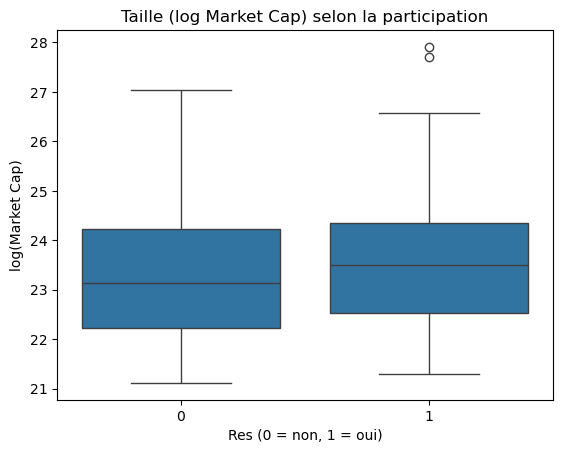

In [30]:
sns.boxplot(x="Res", y=np.log(df["Market_Cap"]), data=df)
plt.title("Taille (log Market Cap) selon la participation")
plt.xlabel("Res (0 = non, 1 = oui)")
plt.ylabel("log(Market Cap)")
plt.show()

Les entreprises répondantes (Res = 1) présentent une capitalisation boursière légèrement plus élevée que les entreprises non répondantes.
Cela suggère que la taille financière joue un rôle positif, mais modéré, dans la participation au CDP.

# 3.2 EMPLOYEES (taille organisationnelle)

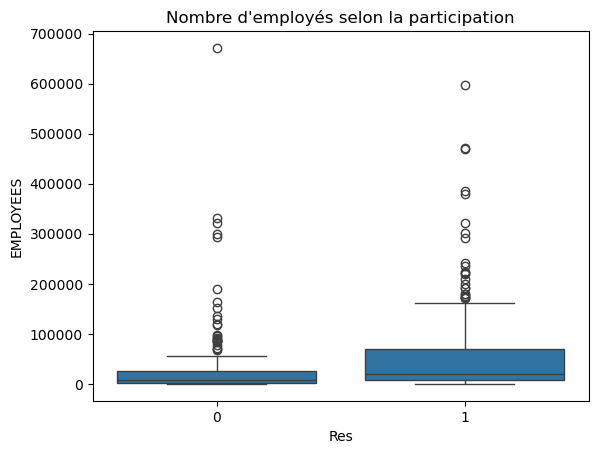

In [31]:
sns.boxplot(x="Res", y="EMPLOYEES", data=df)
plt.title("Nombre d'employés selon la participation")
plt.show()

Les entreprises répondantes présentent en moyenne un nombre d’employés plus élevé que les entreprises non répondantes, malgré une forte dispersion des données.
Cela indique que la taille organisationnelle a un effet positif sur la participation au CDP.

# 3.3 EPS (performance environnementale)

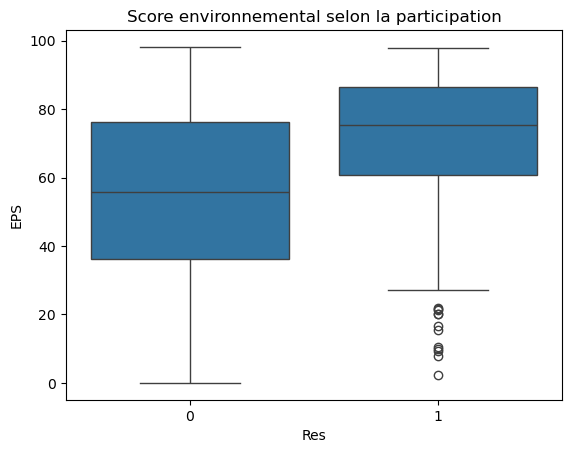

In [32]:
sns.boxplot(x="Res", y="EPS", data=df)
plt.title("Score environnemental selon la participation")
plt.show()

Les entreprises répondantes présentent un score environnemental nettement plus élevé que les entreprises non répondantes.
Cela confirme que la performance environnementale est un facteur déterminant de la participation au CDP.

# 3.4 CSR (gouvernance)

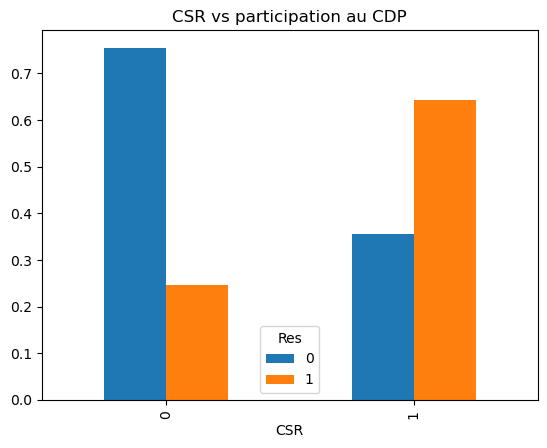

In [33]:
pd.crosstab(df["CSR"], df["Res"], normalize="index").plot(kind="bar")
plt.title("CSR vs participation au CDP")
plt.show()

Les entreprises disposant d’un comité de responsabilité sociale participent beaucoup plus au CDP que celles qui n’en ont pas.
Cela indique que la gouvernance responsable joue un rôle majeur dans la décision de participation.

# 3.5 ROIC (performance financière)

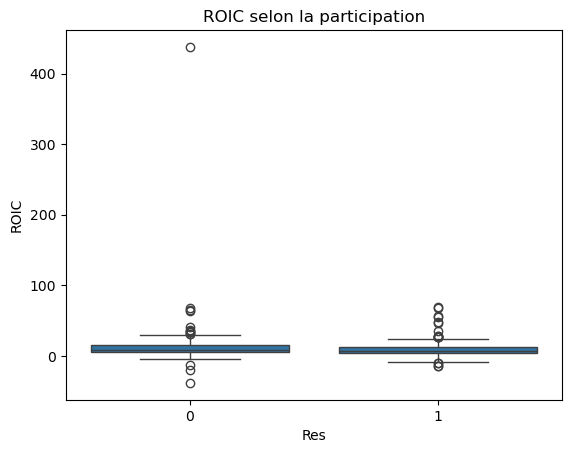

In [34]:
sns.boxplot(x="Res", y="ROIC", data=df)
plt.title("ROIC selon la participation")
plt.show()

La distribution du ROIC est très dispersée et les différences entre entreprises répondantes et non répondantes apparaissent limitées.
Cela suggère que la performance financière a un effet faible sur la participation au CDP.

# 3.6 Board (gouvernance)

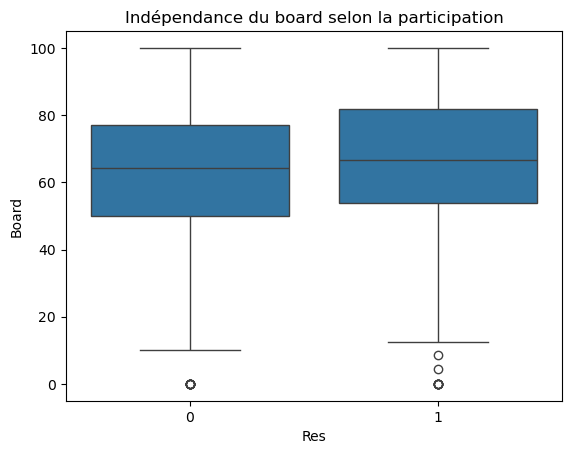

In [35]:
sns.boxplot(x="Res", y="Board", data=df)
plt.title("Indépendance du board selon la participation")
plt.show()

Les entreprises répondantes présentent un niveau légèrement plus élevé d’indépendance du board que les entreprises non répondantes.
Cela suggère que la gouvernance peut jouer un rôle, mais son effet reste modéré.

# OPTIONNEL
Vu que ce projet est lié avec notre github perso, on va sauvegarder quelques images dans fig juste pour un appercu.

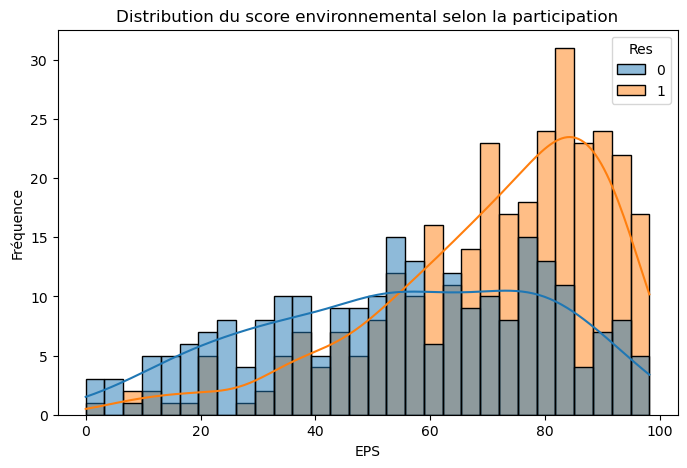

In [41]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="EPS", hue="Res", bins=30, kde=True)

plt.title("Distribution du score environnemental selon la participation")
plt.xlabel("EPS")
plt.ylabel("Fréquence")

plt.savefig("../figures/eps_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

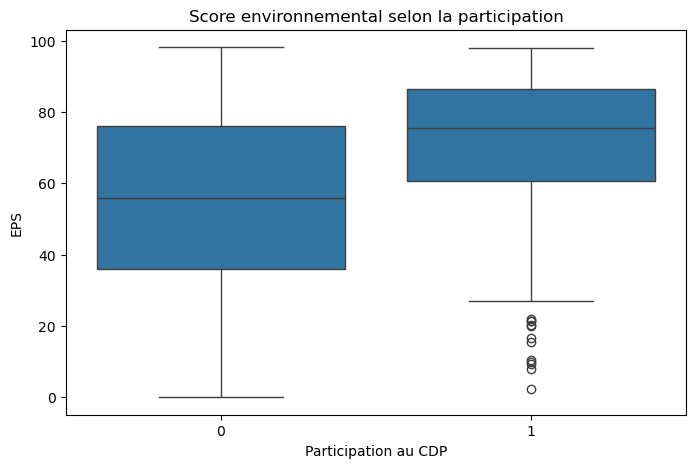

In [42]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Res", y="EPS", data=df)

plt.title("Score environnemental selon la participation")
plt.xlabel("Participation au CDP")
plt.ylabel("EPS")

plt.savefig("../figures/box_eps.png", dpi=300, bbox_inches="tight")
plt.show()

# 4. MÉTHODOLOGIE ÉCONOMÉTRIQUE 

#  4.1 Présentation de l’approche économétrique

L’objectif de cette étude est d’identifier les déterminants de la participation des entreprises au CDP Survey.

L’approche adoptée est une approche explicative, visant à analyser l’effet de différentes caractéristiques des entreprises (performance environnementale, gouvernance, taille, performance financière) sur la probabilité de participation.

Cette approche permet de comprendre les facteurs qui influencent le comportement des entreprises en matière de transparence environnementale, et d’évaluer l’importance relative de chaque variable explicative.

# 4.2 Justification du choix du modèle

La variable dépendante (Res) est une variable binaire prenant la valeur 1 si l’entreprise participe au CDP, et 0 sinon.

Dans ce contexte, l’utilisation d’un modèle linéaire classique présente plusieurs limites, notamment :
- des prédictions pouvant sortir de l’intervalle [0,1],
- une mauvaise spécification de la relation entre les variables explicatives et la probabilité.

Afin de pallier ces limites, un modèle logit est utilisé.

Le modèle logit permet de modéliser directement la probabilité de participation tout en garantissant que les valeurs estimées restent comprises entre 0 et 1. Il permet également de capturer une relation non linéaire entre les variables explicatives et la probabilité.

Ce modèle est particulièrement adapté à l’analyse des variables dépendantes binaires et largement utilisé en économétrie appliquée.

# 4.3 Spécification du modèle

Le modèle estimé est un modèle logit de la forme :

P(Res_i = 1) = F(β0 + β1 Market_Cap_i + β2 EMPLOYEES_i + β3 PROFIT_i + β4 EPS_i + β5 CSR_i + β6 ROIC_i + β7 Board_i)

où F(.) représente la fonction logistique.

Les variables incluses dans le modèle sont :
- Market_Cap : taille financière de l’entreprise,
- EMPLOYEES : taille organisationnelle,
- PROFIT : performance économique,
- EPS : performance environnementale,
- CSR : présence d’un comité de responsabilité sociale,
- ROIC : performance financière,
- Board : structure de gouvernance.

Les hypothèses sous-jacentes sont :
- une relation monotone entre les variables explicatives et la probabilité,
- l’indépendance des observations,
- l’absence de colinéarité excessive entre les variables explicatives.

# 4.4 Modèle saturé

Le modèle saturé correspond au modèle incluant l’ensemble des variables explicatives disponibles.

Il permet d’évaluer l’effet global de toutes les variables sur la probabilité de participation.

Ce modèle sert de point de référence dans la démarche économétrique, avant d’envisager des modèles plus parsimonieux en supprimant les variables non significatives.

# 4.5 Stratégie d’estimation

L’estimation est réalisée de manière progressive.

Dans un premier temps, des modèles simples sont estimés afin d’évaluer l’effet individuel de chaque variable.

Ensuite, un modèle complet (modèle saturé) est estimé en incluant l’ensemble des variables explicatives.

Enfin, des modèles réduits sont construits en supprimant les variables non significatives, afin d’obtenir un modèle plus parcimonieux et économiquement interprétable.

Cette démarche progressive permet d’identifier les variables réellement déterminantes tout en évitant les problèmes de surparamétrisation.

# 4.6 Outils et logiciels

L’analyse économétrique a été réalisée à l’aide du langage Python.

Les principales bibliothèques utilisées sont :
- pandas pour la manipulation des données,
- numpy pour les calculs numériques,
- statsmodels pour l’estimation des modèles économétriques,
- seaborn et matplotlib pour la visualisation des données.

Ces outils permettent une analyse rigoureuse et reproductible.

# 5. ESTIMATION DES MODÈLES

# 5.1 Modèles simples (variable par variable)

In [36]:
import statsmodels.api as sm

# Fonction pour estimer un logit simple
def logit_simple(var):
    X = sm.add_constant(df[[var]])
    y = df["Res"]
    model = sm.Logit(y, X).fit(disp=0)
    return model.summary()

# Liste des variables
variables = ["Market_Cap","EMPLOYEES","PROFIT","EPS","CSR","ROIC","Board"]

for var in variables:
    print(f"\n=== Modèle avec {var} ===")
    print(logit_simple(var))


=== Modèle avec Market_Cap ===
                           Logit Regression Results                           
Dep. Variable:                    Res   No. Observations:                  552
Model:                          Logit   Df Residuals:                      550
Method:                           MLE   Df Model:                            1
Date:                Sun, 03 May 2026   Pseudo R-squ.:               0.0009447
Time:                        12:07:22   Log-Likelihood:                -377.29
converged:                       True   LL-Null:                       -377.64
Covariance Type:            nonrobust   LLR p-value:                    0.3983
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2368      0.095      2.503      0.012       0.051       0.422
Market_Cap   8.11e-13      1e-12      0.811      0.417   -1.15e-12    2.77e-12

=== Modèle avec EMP

Les modèles logit simples permettent d’évaluer l’effet individuel de chaque variable sur la probabilité de participation au CDP.

Concernant la variable Market_Cap, le coefficient estimé n’est pas statistiquement significatif (p-value > 0,05). Cela suggère que la taille financière de l’entreprise, mesurée par la capitalisation boursière, n’a pas d’effet significatif sur la participation lorsqu’elle est considérée isolément.

En revanche, la variable EMPLOYEES présente un effet positif et significatif (pseudo R² plus élevé), indiquant que la taille organisationnelle joue un rôle important dans la participation au CDP.

Enfin, la variable Board apparaît également significative, avec un coefficient positif. Cela suggère que les entreprises ayant une plus grande indépendance du conseil d’administration sont légèrement plus susceptibles de participer au CDP.

Ces résultats confirment partiellement les observations issues de l’analyse exploratoire, en mettant en évidence le rôle de la taille organisationnelle et de la gouvernance, tandis que la taille financière apparaît moins déterminante.

# 5.2 Modèle saturé

In [37]:
X = df[["Market_Cap","EMPLOYEES","PROFIT","EPS","CSR","ROIC","Board"]]
X = sm.add_constant(X)
y = df["Res"]

model_full = sm.Logit(y, X).fit()
print(model_full.summary())

Optimization terminated successfully.
         Current function value: 0.602100
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                    Res   No. Observations:                  552
Model:                          Logit   Df Residuals:                      544
Method:                           MLE   Df Model:                            7
Date:                Sun, 03 May 2026   Pseudo R-squ.:                  0.1199
Time:                        12:11:45   Log-Likelihood:                -332.36
converged:                       True   LL-Null:                       -377.64
Covariance Type:            nonrobust   LLR p-value:                 9.465e-17
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.5110      0.437     -5.745      0.000      -3.368      -1.654
Market_Cap -4.103e-14      1e

Le modèle saturé inclut l’ensemble des variables explicatives afin d’évaluer leur effet conjoint sur la probabilité de participation au CDP.

Le modèle est globalement significatif, comme l’indique la statistique du test de vraisemblance (LLR p-value < 0,01), ce qui confirme la pertinence de l’ensemble des variables.

Parmi les variables explicatives, le score environnemental (EPS) apparaît comme un déterminant majeur. Son coefficient est positif et fortement significatif (p < 0,01), ce qui indique que les entreprises ayant de meilleures performances environnementales ont une probabilité plus élevée de participer au CDP.

La variable CSR est également positive et très significative. Cela confirme que la présence d’un comité de responsabilité sociale joue un rôle central dans la décision de participation.

En revanche, les variables Market_Cap, PROFIT et ROIC ne sont pas significatives, suggérant que la taille financière et la performance économique n’ont pas d’effet direct sur la participation lorsque les autres variables sont contrôlées.

La variable EMPLOYEES présente un effet positif mais non significatif au seuil de 5 %, ce qui indique un rôle plus limité de la taille organisationnelle dans le modèle complet.

Enfin, la variable Board n’est pas significative, ce qui suggère que l’indépendance du conseil d’administration a un impact limité sur la participation.

Dans l’ensemble, ces résultats montrent que la participation au CDP est principalement déterminée par des facteurs environnementaux et de gouvernance, plutôt que par la performance financière.

# 5.3 Modèle réduit

In [38]:
X_reduced = df[["EPS","CSR","EMPLOYEES"]]
X_reduced = sm.add_constant(X_reduced)

model_reduced = sm.Logit(y, X_reduced).fit()
print(model_reduced.summary())

Optimization terminated successfully.
         Current function value: 0.604483
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                    Res   No. Observations:                  552
Model:                          Logit   Df Residuals:                      548
Method:                           MLE   Df Model:                            3
Date:                Sun, 03 May 2026   Pseudo R-squ.:                  0.1164
Time:                        12:13:09   Log-Likelihood:                -333.67
converged:                       True   LL-Null:                       -377.64
Covariance Type:            nonrobust   LLR p-value:                 6.081e-19
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.1594      0.321     -6.730      0.000      -2.788      -1.531
EPS            0.0224      0.

Le modèle réduit a été estimé en conservant les variables les plus pertinentes issues du modèle saturé.

Le modèle est globalement significatif (LLR p-value < 0,01), ce qui confirme sa bonne capacité explicative.

Les résultats montrent que :

- le score environnemental (EPS) reste positif et fortement significatif (p < 0,01). Cela confirme que la performance environnementale est un déterminant majeur de la participation au CDP ;
- la variable CSR est également positive et très significative, indiquant que la présence d’un comité de responsabilité sociale augmente fortement la probabilité de participation ;
- la variable EMPLOYEES présente un coefficient positif mais n’est pas significative au seuil de 5 %, ce qui suggère que l’effet de la taille organisationnelle est plus limité une fois les autres variables contrôlées.

Le modèle réduit présente un pouvoir explicatif proche de celui du modèle saturé (Pseudo R² = 0,116 contre 0,119), ce qui indique que les variables EPS et CSR capturent l’essentiel de l’information pertinente.

Ainsi, le modèle réduit permet de retenir une spécification plus parcimonieuse tout en conservant une forte capacité explicative.

# 5.4 Modèle avec interactions

In [40]:
df["EPS_CSR"] = df["EPS"] * df["CSR"]

X_inter = df[["EPS","CSR","EMPLOYEES","EPS_CSR"]]
X_inter = sm.add_constant(X_inter)

model_inter = sm.Logit(y, X_inter).fit()
print(model_inter.summary())

Optimization terminated successfully.
         Current function value: 0.595003
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                    Res   No. Observations:                  552
Model:                          Logit   Df Residuals:                      547
Method:                           MLE   Df Model:                            4
Date:                Sun, 03 May 2026   Pseudo R-squ.:                  0.1303
Time:                        12:57:03   Log-Likelihood:                -328.44
converged:                       True   LL-Null:                       -377.64
Covariance Type:            nonrobust   LLR p-value:                 2.153e-20
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.9671      0.448     -2.157      0.031      -1.846      -0.088
EPS           -0.0044      0.

Un modèle intégrant une interaction entre le score environnemental (EPS) et la présence d’un comité CSR a été estimé afin d’examiner si l’effet de la performance environnementale dépend de la gouvernance.

Le modèle est globalement significatif (LLR p-value < 0,01) et présente un pouvoir explicatif légèrement supérieur au modèle réduit (Pseudo R² = 0,130 contre 0,116).

Les résultats montrent que :

- les coefficients individuels de EPS et CSR ne sont plus significatifs pris séparément ;
- en revanche, le terme d’interaction (EPS × CSR) est positif et fortement significatif (p < 0,01).

Cela indique que l’effet de la performance environnementale sur la participation au CDP dépend de la présence d’un comité CSR.

Plus précisément, l’impact du score environnemental devient significatif uniquement pour les entreprises disposant d’un comité de responsabilité sociale.

Ces résultats suggèrent un effet complémentaire entre la performance environnementale et la gouvernance : les entreprises qui combinent un engagement environnemental élevé et des structures de gouvernance adaptées sont les plus susceptibles de participer au CDP.

Ainsi, la participation au CDP apparaît comme le résultat d’une interaction entre engagement environnemental et organisation interne.

# 6. ÉVALUATION DES MODÈLES  

Cette section vise à évaluer la qualité des modèles économétriques estimés précédemment.

Trois modèles sont retenus pour l’analyse :
- le modèle saturé,
- le modèle réduit,
- le modèle avec interaction.

Pour chacun de ces modèles, l’évaluation repose sur trois dimensions :
- la significativité des coefficients (individuelle et globale),
- les critères de qualité d’ajustement (AIC, BIC, pseudo R²),
- la performance prédictive (matrice de confusion, courbe ROC, AUC).

Cette démarche permet de comparer les modèles afin de sélectionner la spécification la plus pertinente.

# 6.1 Modèle saturé
# 6.1.1 Significativité

# Individuelle

In [43]:
model_full.pvalues

const         9.203685e-09
Market_Cap    9.673348e-01
EMPLOYEES     1.093343e-01
PROFIT        5.941696e-01
EPS           3.226101e-06
CSR           6.871552e-05
ROIC          6.513885e-01
Board         1.422092e-01
dtype: float64

L’analyse des p-values montre que seules certaines variables sont statistiquement significatives.

Les variables EPS et CSR sont fortement significatives (p < 0,01), ce qui indique qu’elles ont un effet significatif sur la probabilité de participation au CDP.

En revanche, les variables Market_Cap, PROFIT et ROIC ne sont pas significatives (p-value > 0,05), ce qui suggère qu’elles n’ont pas d’effet statistiquement significatif dans le modèle.

Les variables EMPLOYEES et Board présentent des p-values supérieures à 0,05, indiquant une significativité faible.

# Globale

In [44]:
model_full.llr_pvalue

np.float64(9.465416292079767e-17)

Le test du rapport de vraisemblance donne une p-value égale à 9,47e-17, largement inférieure au seuil de 5 %.

Ainsi, l’hypothèse nulle selon laquelle l’ensemble des coefficients est nul est rejetée.

Cela signifie que le modèle est globalement significatif et que les variables explicatives, prises dans leur ensemble, contribuent à expliquer la participation au CDP.

# 6.1.2 Critères de qualité

In [46]:
model_full.aic

np.float64(680.7179589951442)

In [47]:
model_full.bic

np.float64(715.2263433653609)

In [48]:
model_full.prsquared

np.float64(0.11991022830036346)

Le modèle saturé présente un AIC égal à 680,72 et un BIC égal à 715,23.

Ces valeurs relativement faibles indiquent un bon ajustement du modèle aux données, bien qu’elles devront être comparées avec celles des autres modèles pour juger de leur pertinence relative.

Par ailleurs, le pseudo R² est égal à 0,12, ce qui traduit une capacité explicative modérée du modèle.

Cette valeur est cohérente dans le cadre d’un modèle logit, où les pseudo R² sont généralement plus faibles que dans les modèles linéaires.

Ainsi, le modèle saturé offre un compromis acceptable entre qualité d’ajustement et complexité.

# 6.1.3 Performance du modèle

In [51]:
from sklearn.metrics import confusion_matrix, roc_auc_score

# Prédictions
y_pred_prob_full = model_full.predict(X)
y_pred_full = (y_pred_prob_full >= 0.5).astype(int)

# Matrice de confusion
confusion_matrix(df["Res"], y_pred_full)

array([[115, 124],
       [ 48, 265]])

# AUC

In [52]:
from sklearn.metrics import roc_auc_score

roc_auc_score(df["Res"], y_pred_prob_full)

0.7391687943641637

# ROC

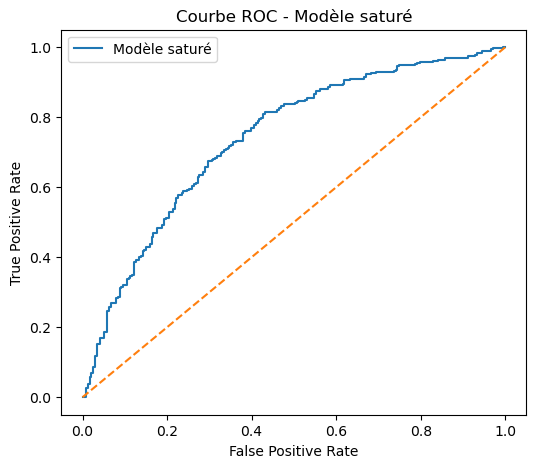

In [53]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(df["Res"], y_pred_prob_full)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="Modèle saturé")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC - Modèle saturé")
plt.legend()
plt.show()

# Analyse de la partie
La matrice de confusion montre que le modèle classe correctement une part importante des observations.

On observe :
- 115 vrais négatifs,
- 265 vrais positifs,
- 124 faux positifs,
- 48 faux négatifs.

Le modèle identifie relativement bien les entreprises répondantes, mais présente davantage d’erreurs pour les entreprises non répondantes.

La courbe ROC est située au-dessus de la diagonale, ce qui indique une capacité de discrimination correcte du modèle.

L’aire sous la courbe (AUC) est égale à 0,739, ce qui traduit une performance satisfaisante.

Ainsi, le modèle saturé présente une capacité de classification globalement correcte, bien qu’améliorable.

# 6.2 Modèle réduit
# 6.2.1 Significativité
# individuelle

In [54]:
model_reduced.pvalues

const        1.692519e-11
EPS          1.622515e-06
CSR          4.110001e-05
EMPLOYEES    1.146026e-01
dtype: float64

L’analyse des p-values du modèle réduit montre que les variables EPS et CSR sont fortement significatives (p < 0,01).

Cela indique qu’elles ont un effet significatif sur la probabilité de participation au CDP.

En revanche, la variable EMPLOYEES n’est pas significative au seuil de 5 % (p-value > 0,05), ce qui suggère un effet plus limité.

# Globale

In [55]:
model_reduced.llr_pvalue

np.float64(6.0809638196174015e-19)

Le test du rapport de vraisemblance donne une p-value égale à 6,08e-19, largement inférieure au seuil de 5 %.

Ainsi, l’hypothèse nulle selon laquelle l’ensemble des coefficients est nul est rejetée.

Le modèle est donc globalement significatif.

# 6.2.2 Critères de qualité

In [57]:
model_reduced.aic

np.float64(675.3489741819267)

In [58]:
model_reduced.bic

np.float64(692.6031663670351)

In [59]:
model_reduced.prsquared

np.float64(0.11642675155095517)

Le modèle réduit présente un AIC égal à 675,35 et un BIC égal à 692,60.

Ces valeurs sont inférieures à celles du modèle saturé, ce qui indique une amélioration de la qualité d’ajustement malgré un nombre de variables plus faible.

Par ailleurs, le pseudo R² est égal à 0,116, une valeur très proche de celle du modèle saturé.

Cela suggère que le modèle réduit conserve l’essentiel de la capacité explicative tout en étant plus parcimonieux.

Ainsi, le modèle réduit apparaît comme un bon compromis entre simplicité et performance.

6.2.3 Performance

In [61]:
# prédictions
y_pred_prob_red = model_reduced.predict(X_reduced)
y_pred_red = (y_pred_prob_red >= 0.5).astype(int)

In [62]:

from sklearn.metrics import confusion_matrix, roc_auc_score
confusion_matrix(df["Res"], y_pred_red)


array([[115, 124],
       [ 47, 266]])

In [63]:
roc_auc_score(df["Res"], y_pred_prob_red)

0.7354391968666033

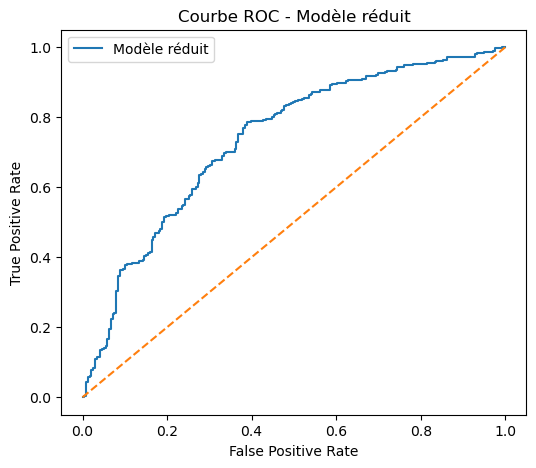

In [64]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(df["Res"], y_pred_prob_red)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="Modèle réduit")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC - Modèle réduit")
plt.legend()
plt.show()

La matrice de confusion montre que le modèle classe correctement une part importante des observations.

On observe :
- 115 vrais négatifs,
- 266 vrais positifs,
- 124 faux positifs,
- 47 faux négatifs.

Le modèle présente une capacité de classification similaire à celle du modèle saturé.

La courbe ROC est située au-dessus de la diagonale, indiquant une capacité de discrimination correcte.

L’aire sous la courbe (AUC) est égale à 0,735, ce qui traduit une performance satisfaisante.

Ainsi, le modèle réduit conserve une bonne capacité prédictive tout en étant plus simple.

# 6.3 Modèle avec interaction

# 6.3.1 Significativité

# Individuelle

In [65]:
model_inter.pvalues

const        0.030983
EPS          0.646941
CSR          0.275438
EMPLOYEES    0.152314
EPS_CSR      0.001333
dtype: float64

L’analyse des p-values du modèle avec interaction montre que le terme d’interaction EPS_CSR est statistiquement significatif (p < 0,01).

En revanche, les variables EPS, CSR et EMPLOYEES ne sont pas significatives prises individuellement (p-value > 0,05).

Ce résultat est cohérent en présence d’un terme d’interaction, où l’effet des variables dépend de leur combinaison.

# Globale

In [66]:
model_inter.llr_pvalue

np.float64(2.1534167165116132e-20)

Le test du rapport de vraisemblance donne une p-value égale à 2,15e-20, largement inférieure au seuil de 5 %.

Ainsi, l’hypothèse nulle selon laquelle l’ensemble des coefficients est nul est rejetée.

Le modèle est donc globalement significatif.

# 6.3.2 Critères de qualité

In [67]:
model_inter.aic

np.float64(666.8829188571001)

In [68]:
model_inter.bic

np.float64(688.4506590884856)

In [69]:
model_inter.prsquared

np.float64(0.13028385909074058)

Le modèle avec interaction présente un AIC égal à 666,88 et un BIC égal à 688,45.

Ces valeurs sont inférieures à celles du modèle saturé et du modèle réduit, ce qui indique une amélioration de la qualité d’ajustement.

Par ailleurs, le pseudo R² est égal à 0,130, soit une valeur plus élevée que celle des autres modèles.

Cela suggère que l’introduction du terme d’interaction permet de mieux expliquer la participation au CDP.

Ainsi, le modèle avec interaction offre la meilleure qualité d’ajustement parmi les modèles étudiés.

# 6.3.3 Performance

In [70]:
y_pred_prob_int = model_inter.predict(X_inter)
y_pred_int = (y_pred_prob_int >= 0.5).astype(int)

from sklearn.metrics import confusion_matrix, roc_auc_score

In [71]:
confusion_matrix(df["Res"], y_pred_int)

array([[128, 111],
       [ 60, 253]])

In [72]:
roc_auc_score(df["Res"], y_pred_prob_int)

0.7373908858796636

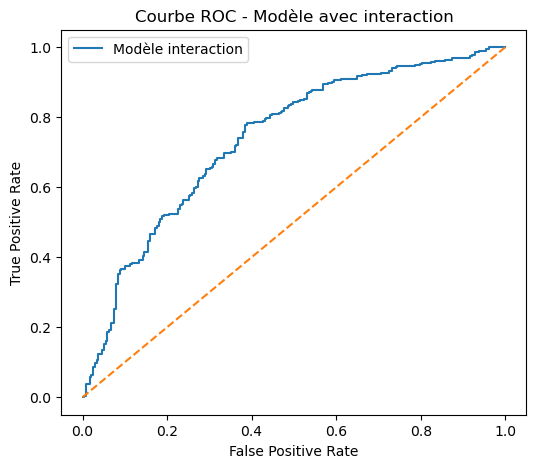

In [73]:

fpr, tpr, _ = roc_curve(df["Res"], y_pred_prob_int)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="Modèle interaction")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC - Modèle avec interaction")
plt.legend()
plt.show()

La matrice de confusion montre que le modèle classe correctement une part importante des observations.

On observe :
- 128 vrais négatifs,
- 253 vrais positifs,
- 111 faux positifs,
- 60 faux négatifs.

Le modèle présente une capacité de classification correcte, avec une meilleure identification des entreprises non répondantes que dans les modèles précédents.

La courbe ROC est située au-dessus de la diagonale, ce qui indique une capacité de discrimination satisfaisante.

L’aire sous la courbe (AUC) est égale à 0,737, ce qui traduit une performance globale satisfaisante.

Ainsi, le modèle avec interaction conserve une bonne capacité prédictive tout en améliorant la qualité d’ajustement.

# 7. INTERPRÉTATION ÉCONOMIQUE
# 7.1 Signes des coefficients

## Modèle saturé

In [75]:
model_full.params

const        -2.511031e+00
Market_Cap   -4.103155e-14
EMPLOYEES     2.447081e-06
PROFIT        1.041317e-03
EPS           2.221808e-02
CSR           1.093170e+00
ROIC         -3.174744e-03
Board         6.098825e-03
dtype: float64

L’analyse des coefficients du modèle saturé montre que :

- les variables EPS et CSR présentent des coefficients positifs, indiquant qu’une amélioration du score environnemental et la présence d’un comité CSR augmentent la probabilité de participation au CDP ;

- la variable EMPLOYEES présente également un coefficient positif, suggérant qu’une entreprise de plus grande taille a une probabilité plus élevée de participation ;

- les variables Market_Cap, PROFIT et ROIC présentent des coefficients proches de zéro ou négatifs, traduisant un effet faible ou incertain sur la participation ;

- la variable Board présente un effet positif mais de faible amplitude.

Ainsi, les principaux effets positifs sont liés à la performance environnementale et à la gouvernance.

#### Modèle réduit

In [76]:
model_reduced.params

const       -2.159363
EPS          0.022416
CSR          1.108995
EMPLOYEES    0.000002
dtype: float64

Dans le modèle réduit, les coefficients associés aux variables EPS et CSR sont positifs, confirmant leur effet favorable sur la probabilité de participation au CDP.

La variable EMPLOYEES présente également un coefficient positif, indiquant qu’une entreprise de plus grande taille est plus susceptible de participer.

Les signes des coefficients sont cohérents avec ceux observés dans le modèle saturé, ce qui renforce la robustesse des résultats.

Ainsi, les variables liées à la performance environnementale et à la gouvernance apparaissent comme les principaux déterminants de la participation.

## Modèle avec interaction

In [77]:
model_inter.params

const       -0.967118
EPS         -0.004371
CSR         -0.639392
EMPLOYEES    0.000002
EPS_CSR      0.035182
dtype: float64

Dans le modèle avec interaction, le coefficient du terme d’interaction EPS_CSR est positif, ce qui indique que la combinaison d’un score environnemental élevé et de la présence d’un comité CSR augmente fortement la probabilité de participation.

En revanche, les coefficients de EPS et CSR pris individuellement deviennent négatifs ou non significatifs.

Ce résultat est cohérent en présence d’une interaction, où l’effet des variables dépend de leur combinaison plutôt que de leur effet isolé.

# 7.2 Significativité

## Modèle saturé

Dans le modèle saturé, les variables EPS et CSR sont statistiquement significatives au seuil de 5 %, indiquant qu’elles ont un effet significatif sur la probabilité de participation au CDP.

Les autres variables (Market_Cap, PROFIT, ROIC, EMPLOYEES et Board) ne sont pas significatives, ce qui suggère un effet limité lorsqu’elles sont prises individuellement.

Le modèle est globalement significatif, comme l’indique le test du rapport de vraisemblance.

#### Modèle réduit

Dans le modèle réduit, les variables EPS et CSR restent fortement significatives.

La variable EMPLOYEES n’est pas significative au seuil de 5 %, ce qui confirme que son effet est secondaire.

Le modèle est globalement significatif.

#### Modèle avec interaction

Dans le modèle avec interaction, le terme d’interaction EPS_CSR est statistiquement significatif, tandis que les variables EPS et CSR prises individuellement ne le sont plus.

Ce résultat est cohérent avec la présence d’un effet d’interaction, où l’impact des variables dépend de leur combinaison.

Le modèle est globalement significatif, indiquant que les variables explicatives contribuent ensemble à expliquer la participation au CDP.

# 7.3 Odds Ratio

Les odds ratios permettent d’interpréter les coefficients du modèle logit en termes d’effet multiplicatif sur les chances de participation.

In [79]:
np.exp(model_full.params)

const         0.081184
Market_Cap    1.000000
EMPLOYEES     1.000002
PROFIT        1.001042
EPS           1.022467
CSR           2.983717
ROIC          0.996830
Board         1.006117
dtype: float64

Dans le modèle saturé, l’odds ratio associé à la variable EPS est supérieur à 1 (≈ 1,02), ce qui indique qu’une augmentation du score environnemental augmente les chances de participation au CDP.

La variable CSR présente un odds ratio proche de 3, ce qui signifie que les entreprises disposant d’un comité CSR ont environ trois fois plus de chances de participer.

Les autres variables ont des odds ratios proches de 1, indiquant un effet limité.

In [80]:
np.exp(model_reduced.params)

const        0.115399
EPS          1.022670
CSR          3.031311
EMPLOYEES    1.000002
dtype: float64

Dans le modèle réduit, les résultats sont similaires.

L’odds ratio de EPS est supérieur à 1, confirmant son effet positif.

La variable CSR présente également un odds ratio élevé (≈ 3), ce qui confirme son rôle déterminant dans la participation.

La variable EMPLOYEES a un odds ratio très proche de 1, traduisant un effet faible.

In [81]:
np.exp(model_inter.params)

const        0.380177
EPS          0.995638
CSR          0.527613
EMPLOYEES    1.000002
EPS_CSR      1.035809
dtype: float64

Dans le modèle avec interaction, l’odds ratio associé au terme EPS_CSR est supérieur à 1 (≈ 1,036), ce qui indique que la combinaison d’un score environnemental élevé et de la présence d’un comité CSR augmente les chances de participation.

Les odds ratios de EPS et CSR pris individuellement sont inférieurs ou proches de 1, ce qui confirme que leur effet dépend principalement de leur interaction.

### 7.4 Effets marginaux

Les effets marginaux permettent d’interpréter l’impact des variables explicatives en termes de variation de probabilité de participation au CDP.

In [83]:
model_full.get_margeff().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
        Logit Marginal Effects       
=====================================
Dep. Variable:                    Res
Method:                          dydx
At:                           overall
==============================================================================
                dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Market_Cap -8.501e-15   2.08e-13     -0.041      0.967   -4.15e-13    3.98e-13
EMPLOYEES    5.07e-07   3.14e-07      1.613      0.107   -1.09e-07    1.12e-06
PROFIT         0.0002      0.000      0.533      0.594      -0.001       0.001
EPS            0.0046      0.001      5.024      0.000       0.003       0.006
CSR            0.2265      0.054      4.206      0.000       0.121       0.332
ROIC          -0.0007      0.001     -0.452      0.651      -0.004       0.002
Board          0.0013      0.001      1.478      0.140      -0.000       0.003
==============================================================================
"""

Dans le modèle saturé, les effets marginaux montrent que les variables EPS et CSR ont un impact positif et significatif sur la probabilité de participation au CDP. En particulier, la présence d’un comité CSR augmente fortement cette probabilité, tandis que les autres variables ont des effets faibles ou non significatifs.

In [84]:
model_reduced.get_margeff().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
        Logit Marginal Effects       
=====================================
Dep. Variable:                    Res
Method:                          dydx
At:                           overall
==============================================================================
                dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
EPS            0.0047      0.001      5.200      0.000       0.003       0.006
CSR            0.2309      0.053      4.348      0.000       0.127       0.335
EMPLOYEES   5.001e-07   3.15e-07      1.589      0.112   -1.17e-07    1.12e-06
==============================================================================
"""

Dans le modèle réduit, les effets marginaux indiquent que les variables EPS et CSR ont un impact positif et significatif sur la probabilité de participation au CDP. En revanche, la variable EMPLOYEES présente un effet positif mais non significatif, traduisant une influence limitée.

In [85]:
model_inter.get_margeff().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
        Logit Marginal Effects       
=====================================
Dep. Variable:                    Res
Method:                          dydx
At:                           overall
==============================================================================
                dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
EPS           -0.0009      0.002     -0.458      0.647      -0.005       0.003
CSR           -0.1301      0.119     -1.095      0.274      -0.363       0.103
EMPLOYEES   4.436e-07   3.08e-07      1.440      0.150    -1.6e-07    1.05e-06
EPS_CSR        0.0072      0.002      3.320      0.001       0.003       0.011
==============================================================================
"""

Dans le modèle avec interaction, l’effet marginal du terme EPS_CSR est positif et significatif, indiquant que la combinaison entre performance environnementale et comité CSR augmente la probabilité de participation au CDP. Les effets individuels de EPS et CSR ne sont pas significatifs, ce qui confirme que leur impact dépend principalement de leur interaction.

# 7.5 Interprétation économique des résultats

Les résultats montrent que la participation au CDP est principalement déterminée par des facteurs liés à l’engagement environnemental et à la gouvernance.

Les entreprises présentant un score environnemental élevé sont plus susceptibles de participer au CDP, ce qui traduit une volonté accrue de transparence et de communication sur leurs performances environnementales.

La présence d’un comité CSR joue également un rôle central en renforçant significativement la probabilité de participation.

L’introduction d’un terme d’interaction met en évidence que ces deux dimensions ne sont pas indépendantes : c’est leur combinaison qui explique le mieux la participation.

Ainsi, les entreprises les plus engagées en matière de performance environnementale et de gouvernance responsable sont celles qui adoptent le plus fréquemment des comportements de transparence, tels que la participation au CDP.

# 8. Choix du meilleur modèle

# Comparaison des modèles

In [86]:


comparison = pd.DataFrame({
    "Modèle": ["Saturé", "Réduit", "Interaction"],
    "AIC": [model_full.aic, model_reduced.aic, model_inter.aic],
    "BIC": [model_full.bic, model_reduced.bic, model_inter.bic],
    "Pseudo R²": [model_full.prsquared, model_reduced.prsquared, model_inter.prsquared],
    "AUC": [0.739, 0.735, 0.737]
})

comparison

,Modèle,AIC,BIC,Pseudo R²,AUC
0,Saturé,680.717959,715.226343,0.119910,0.739
1,Réduit,675.348974,692.603166,0.116427,0.735
2,Interaction,666.882919,688.450659,0.130284,0.737


Le tableau montre que le modèle avec interaction présente les meilleurs critères d’ajustement, avec l’AIC et le BIC les plus faibles ainsi que le pseudo R² le plus élevé.

Les performances prédictives, mesurées par l’AUC, sont très proches entre les trois modèles.

# Justification du choix final

Au regard de ces résultats, le modèle avec interaction est retenu comme modèle final.

Ce choix se justifie par :
- une meilleure qualité d’ajustement,
- une capacité explicative plus élevée,
- une modélisation plus réaliste de la relation entre performance environnementale et gouvernance.

Ainsi, le modèle avec interaction apparaît comme le plus pertinent pour expliquer la participation au CDP.

# Conclusion

# Résultats principaux

Ce travail avait pour objectif d’identifier les déterminants de la participation des entreprises au CDP.

Les résultats montrent que la participation est principalement influencée par la performance environnementale (EPS) et la présence d’un comité CSR.

L’analyse met en évidence que c’est la combinaison de ces deux facteurs qui explique le mieux la participation.

# Réponse à la problématique

La participation au CDP s’explique essentiellement par le niveau d’engagement environnemental et la qualité de la gouvernance des entreprises.

Les entreprises les plus engagées sont celles qui adoptent des pratiques de transparence.

# Limites

Ce travail présente certaines limites.

Les données utilisées sont transversales et ne permettent pas d’analyser les évolutions dans le temps.

De plus, certaines variables explicatives pertinentes peuvent ne pas être prises en compte.

# Ouverture

Ce travail pourrait être prolongé par l’utilisation de données de panel afin d’analyser l’évolution du comportement des entreprises dans le temps.

L’intégration de variables institutionnelles ou sectorielles permettrait également d’enrichir l’analyse.